# **EBRAINS demonstrator: Sensorimotor neurocontroller**

In this tutorial, we progressively explore a **biologically grounded, spiking, closed-loop neurocontroller** designed to investigate adaptive sensorimotor behavior in a **multiple-target reaching task** subjected to **perturbation forces**. The architecture models distinct brain regions and their functional interactions during task execution, continuously integrating sensory feedback from the body with internally generated neural signals to regulate the movement of a simulated robotic limb.

This notebook introduces the controller's components **step by step**, moving from its **high-level architecture** down to the **individual neural circuits** and **their interactions**. Through a series of hands-on examples, simulations, and visualizations of pre-trained results, we show how adaptive motor control emerges within the system.

# **Introduction**

**Motor control** is a complex function emerging from the coordinated activity of multiple areas of the central nervous system (CNS). Among these regions, the **cerebellum** acts as the ***puppet master***: it integrates heterogeneous sensory and motor inputs from various brain areas, building an **internal representation of body–environment interactions**. This representation takes the form of **internal models**: neural constructs that capture the relationship between motor commands and their expected sensory consequences. Through this process, the cerebellum learns to **predict the sensorimotor consequences** of a movement, enabling **predictive** rather than reactive **movement generation**.

<div style="display: flex; justify-content: center; gap: 20px; align-items: center;">
    <img src="notebooks/imgs/human_movement_without_writings.jpg" width="28%">
    <img src="notebooks/imgs/motor_control_pathways.jpg" width="35%">
</div>

A comprehensive understanding of these mechanisms requires **linking cerebellar neural dynamics to motor behavior**, effectively bridging computational models of neural activity with the physical actions that emerge from them. 
**Neurocontroller** development offers a principled way to build this bridge, providing a framework in which **neural dynamics** is **directly related to their behavioral output** in a **closed-loop**.

## Neurocontroller architecture

The proposed neurocontroller integrates an **AI-based Planner**, representing the premotor cortex within the motor control loop; a **motor command generator** with both feedforward motor command generation and feedback computation strategies; and **two Spiking Neural Network cerebellar circuits**, implementing a forward and an inverse internal model, respectively:

* **forward model:** 
    * **aim:** predict joint position to compensate for sensory delay
    * **input:** current motor command + mismatch between predicted and actual joint position
    * **output:** predicted joint-angle variation.

* **inverse model:**
    * **aim**: correct motor commands and compensate for perturbations;
    * **input:** planned trajectory + mismatch between ideal and estimated position;
    * **output:** corrective signal for motor commands.


 This system operates in a closed-loop with a **1 degree of freedom virtual limb** through the **NeuroRobotic Platform (NRP)**, which interfaces neural activity with physical body movements.

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="notebooks/imgs/whole_controller_schema.PNG" width="70%">
</div>

| MODULE | FRAMEWORK | ROLE | LEARNING |
|:---:|:---:|:---:|:---:|
| **Action selection & Planning** | PyTorch | Object recognition and trajectory generation based on visual input | Learn **offline** through GLE strategy (biologically plausible approximation of backpropagation)  
| **Motor Command Generator** | NEST | Generation of motor commands needed to execute a trajectory | Learn **offline** through e-prop (eligibility propagation) strategy (biologically plausible approximation of backpropagation)  
| **Cerebellar models** | NEST | Sensorimotor prediction based on error-driven learning |Learn **online** within each trial through synaptic weights evlution; weights persist across chained trials | Network pre-compiled by BSB (Brain Scaffold Builder) framework into an HDF5 topology and instantiated at run setup 
| **Plant (Robotic embodiment)** | PyBullet | Simulation of a robotic arm with 1-DoF (elbow flexion and extention); rendered-view fidelity for planner visual input | \ |

# **Action selection & Planning**

In this section, we explore the **implementation and inner workings of the trajectory planner for the robotic arm**. Within our overall controller architecture, this module emulates the functional roles of key cortical and subcortical structures, specifically the **prefrontal cortex**, **premotor cortex**, and **basal ganglia**.

---

## Robotic Arm Trajectory Planner 

Given a **2D RGB image** of the scene (body + environment), the planner outputs the object identification and the best strategy, specifically the selection of the elbow joint trajectory formatted as a **minimum jerk profile** (the standard biological point-to-point motion curve that produces smooth, bell-shaped velocity profiles by minimizing changes in acceleration). 

### Pipeline Decomposition

The end-to-end task (*visual scene $\to$ full joint trajectory*) is naturally split into two stages:

1. **Perception Module:** Extracts low-dimensional, task-relevant state variables from the high-dimensional RGB image (e.g., initial joint angle $\theta_0$, target angle $\theta_f$, and action choice).
2. **Motor Generation Module:** Generates the smooth temporal sequence of joint angles over a fixed duration based on the extracted boundary states.


### Training via Generalized Latent Equilibrium (GLE)

Both modules are trained using **Generalized Latent Equilibrium (GLE)** rather than conventional backpropagation. Here, the traditional static artificial neurons are redesigned into a continuous dynamical units:

* **Leaky Membrane Integration:** Instead of static feedforward activation functions ($a = f(Wx)$), each computational unit maintains a continuous membrane potential state variable $u_i(t)$ governed by a passive time constant $\tau_m$:
  $$\tau_m \frac{du_i(t)}{dt} = -u_i(t) + \underbrace{\sum_j W_{ij} x_j(t)}_{I_{\text{syn}, i}(t)\text{ (total afferent synaptic drive)}}$$
  where the total afferent synaptic drive $I_{\text{syn}, i}(t)$ (presynaptic activity $x_j(t)$ weighted by synaptic efficacies $W_{ij}$) is leaky-integrated over time rather than instantaneously mapped to an output.
* **Dual-Stream Unit Architecture:** The classical single-output node is replaced by a dual-stream microcircuit that concurrently tracks a feedforward **representation stream** and an **error stream**, allowing simultaneous inference and error evaluation.
* **Local Learning (No Global Supervisor):** Standard training requires a centralized algorithm (autodiff) that has full access to the entire network's weights. In GLE, connections update themselves using only information immediately available at that specific connection—just like real synapses responding to local neighboring activity.
* **Equilibrium-Driven Plasticity:** Synaptic updates do not require a separate autograd sweep across the graph; learning emerges as the units' internal states settle toward an equilibrium over continuous time steps.

## 1. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
from pathlib import Path
from PIL import Image
import random
import math
from pfc_planner.trajectory_generators import MinJerkTrajectoryGenerator
from pfc_planner.planners import GLEPlanner, GLEVisionNet
from pfc_planner.config import default_params
from pfc_planner.factory import get_planner

params = default_params

# URDF assets ship inside the controller package:
# controller/src/neurocontroller/embodiment_assets/{skeleton.urdf, plane.urdf}
ASSETS_DIR = Path("src/neurocontroller/embodiment_assets")
PLANNER_MODEL_DIR = Path("submodules/pfc_planner/models")

SHOULDER_JOINT, ELBOW_JOINT, HAND_LINK = 0, 1, 3
TARGET_COLOR = {"blue": (0, 0, 1, 1), "red": (1, 0, 0, 1)}  # BLUE_LEFT / RED_RIGHT

pybullet build time: Jan 29 2025 23:16:28


## 2. Data creation and visualization

In [2]:
def render_scene(init_angle_deg, target_angle_deg, color_label,
                  target_visual_offset_deg=4.0, image_path="input_image.bmp"):

    client = p.connect(p.DIRECT) # DIRECT runs the physics engine in-process with no interactive visualization
    p.setGravity(0, 0, 0, physicsClientId=client)          # ExperimentParams.enable_gravity=False by default
    p.setAdditionalSearchPath(str(ASSETS_DIR), physicsClientId=client)  # set the path where take the models 

    ## LOAD THE 1-DoF ARM MODEL & SET IT IN THE SPACE

    # NOTE: We set useFixedBase in order to keep the robot's torso locked in a specific
    # position, rather than letting it translate and tumble freely through space
    # (like a physical object dropped into the scene).
    robot = p.loadURDF("skeleton.urdf", useFixedBase=True, physicsClientId=client) 
    p.resetBasePositionAndOrientation(robot, [0, 0, 0], [0, 0, 0, 1], physicsClientId=client)

    # remove the implicit default motor, set by PyBullet to every revolute/prismatic joint the moment a model is loaded
    # NOTE:  we want to remove it in order to move the joints as we want, without resistence of their own
    p.setJointMotorControlArray(robot, [SHOULDER_JOINT, ELBOW_JOINT],
                                 p.POSITION_CONTROL, forces=[0, 0], physicsClientId=client)
    p.setJointMotorControlArray(robot, [SHOULDER_JOINT, ELBOW_JOINT],
                                 p.VELOCITY_CONTROL, forces=[0, 0], physicsClientId=client)

    ## LOAD A FLAT PLANE & PLACE IT 
    plane = p.loadURDF("plane.urdf", useFixedBase=True, physicsClientId=client) 
    p.resetBasePositionAndOrientation(
        plane, [0, 10, 10], p.getQuaternionFromEuler([np.pi / 2, 0, 0]), physicsClientId=client
    ) # put a 90° rotation about the x-axis

    ## FIND POSITION WHERE THE BALL WILL BE PLACED
    # place elbow at target+offset just to read the hand (end-effector) position
    target_rad = np.deg2rad(target_angle_deg) + np.deg2rad(target_visual_offset_deg)
    p.resetJointState(robot, ELBOW_JOINT, target_rad, physicsClientId=client) 
    ball_position = p.getLinkState(robot, HAND_LINK, physicsClientId=client)[0]

    ## CREATE THE COLOR TARGET BALL
    # definition of the appearance
    ball_shape = p.createVisualShape(p.GEOM_SPHERE, radius=0.02,
                                      rgbaColor=TARGET_COLOR[color_label], physicsClientId=client) 
    # instantiation of the ball as an actual object in the scene 
    # NOTE: baseMass=0 makes it static/immovable
    #       baseCollisionShapeIndex=-1 makes it purely decorative -> it will never physically interact with the arm
    p.createMultiBody(baseMass=0, baseCollisionShapeIndex=-1,
                       baseVisualShapeIndex=ball_shape, basePosition=ball_position,
                       physicsClientId=client) 
                                                
    ## RESTORE THE INITIAL POSITION
    # final resting pose for the snapshot: elbow back at the *initial* angle
    p.resetJointState(robot, ELBOW_JOINT, np.deg2rad(init_angle_deg), physicsClientId=client)
    p.resetJointState(robot, SHOULDER_JOINT, 0.0, physicsClientId=client)

    ## SET THE VIRTUAL CAMERA
    # Set tha camera exactly as _capture_state_and_save does (function present in src/neurocontroller/plant/robotic_plant.py)
    camera_target, camera_pos, up = [0.3, 0.3, 1.5], [0, -1, 1.7], [0, 0, 1]
    width, height, fov, near, far = 1024, 768, 60, 0.1, 100
    proj = p.computeProjectionMatrixFOV(fov, width / height, near, far) # build perspective projection matrix
    view = p.computeViewMatrix(camera_pos, camera_target, up) # cuild the corresponding view

    ## OBTAIN THE IMAGE (CAPTURE)
    # NOTE: ER_TINY_RENDER is PyBullet's software (CPU) rasterizer 
    # (takes vector-based shapes or 3D models and converts them into a grid of pixels = a raster image)
    img = p.getCameraImage(width, height, viewMatrix=view, projectionMatrix=proj,
                            renderer=p.ER_TINY_RENDERER, physicsClientId=client)
    rgb = np.array(img[2])[:, :, :3] # take the RGB NumPy array (the alpha channel, representing the opacity/trasparency of img, is removed)
    Image.fromarray(rgb.astype(np.uint8)).save(image_path)
    p.disconnect(client)


Visualizing a few data samples...
The capture of the robot already exists
The capture of the robot already exists


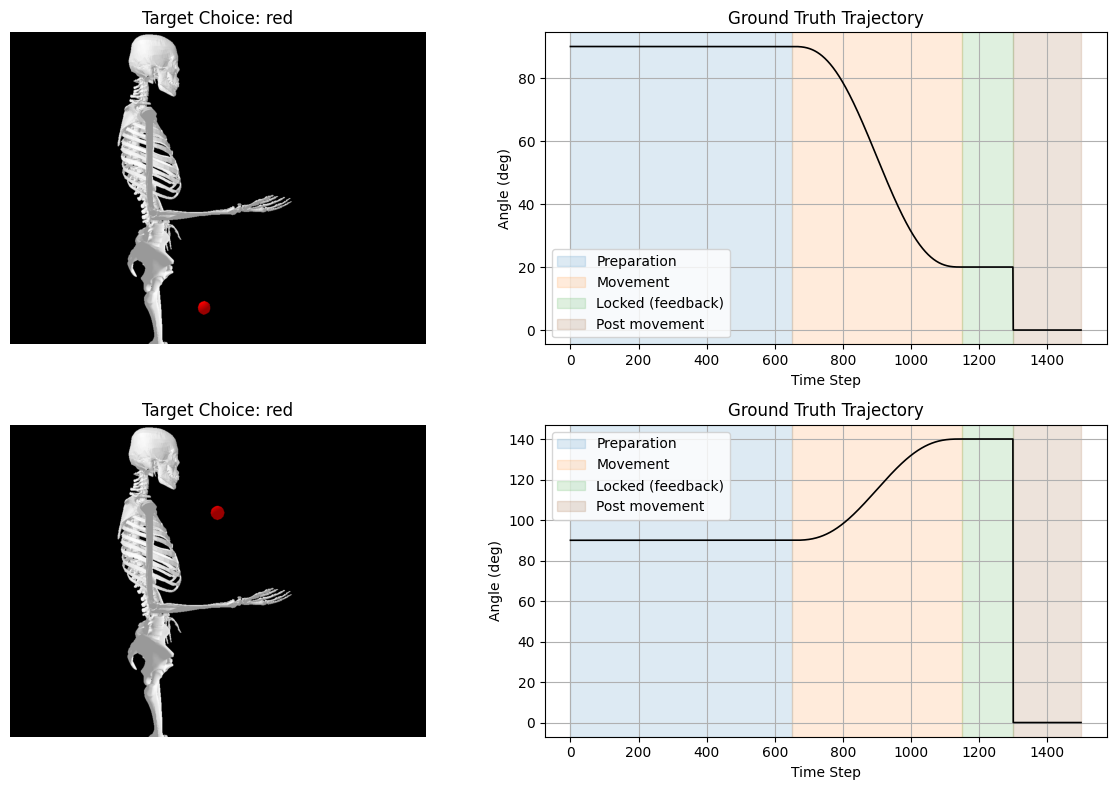

In [8]:
# Reproduces one cell of the imagedata_gen.py sweep, e.g. filename "90_20_blue.bmp"
angles = [(90, 20), (90, 140)]
#colours = ["red", "blue"]
colour = "red"
# timing subdivision
time_prep_steps = int(params.time_prep / params.resolution)
time_move_end_steps = int((params.time_prep + params.time_move) / params.resolution)
time_locked_with_feedback_end_steps = int((time_move_end_steps + params.time_locked_with_feedback) / params.resolution)


task_data = {
    "imgs_path": [],
    "target_choice": [],
    "traj_target": []
}

# --- Visualize a few data samples --- #
print("\nVisualizing a few data samples...")
num_samples_to_show = len(angles)
fig, axes = plt.subplots(num_samples_to_show, 2, figsize=(12, 4 * num_samples_to_show))
if num_samples_to_show == 1: axes = [axes] # make it iterable

for i, couple in enumerate(angles):
    angle_in = couple[0]
    angle_end = couple[1]
    #colour = random.choice(colours)
    img_name = str(angle_in) + "_" + str(angle_end) + "_" + colour + ".bmp"
    img_complete_path = Path("notebooks/imgs/" + img_name)

    # add to the dictionary the image path
    task_data["imgs_path"].append(img_complete_path)
    task_data["target_choice"].append(colour)

    if img_complete_path.exists():
        print("The capture of the robot already exists")
    else:
        render_scene(init_angle_deg=angle_in, target_angle_deg=angle_end, color_label=colour,
                    image_path=img_complete_path)

    angle_in_rad = math.radians(angle_in)
    angle_end_rad = math.radians(angle_end)

    minjerk = MinJerkTrajectoryGenerator(params)
    target_traj = minjerk.angles_to_trajectory(angle_in_rad, angle_end_rad)

    # add to the dictionary the generated trajectory (ground truth)
    task_data["traj_target"].append(target_traj)

    # Plot image
    image = Image.open(img_complete_path)
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Target Choice: {colour}")
    axes[i, 0].axis('off')

    # Plot trajectory
    # Define segment boundaries and labels
    boundaries = [0, time_prep_steps, time_move_end_steps, time_locked_with_feedback_end_steps-1, len(target_traj)]
    labels = ["Preparation", "Movement", "Locked (feedback)", "Post movement"]
    #colors = ["#4C72B0", "#55A868", "#DD8452", "#A0785A"]
    colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#8B4513"]

    axes[i, 1].plot(np.rad2deg(target_traj), color="black", linewidth=1.2, zorder=3)
    for start, end, label, color in zip(boundaries[:-1], boundaries[1:], labels, colors):
        axes[i, 1].axvspan(start, end, color=color, alpha=0.15, label=label, zorder=0)

    #axes[i, 1].plot(target_traj)
    axes[i, 1].set_title("Ground Truth Trajectory")
    axes[i, 1].set_xlabel("Time Step")
    axes[i, 1].set_ylabel("Angle (deg)")
    axes[i, 1].grid(True, zorder=1)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## 3. Trajectories generation and evaluation

--- Setting up Evaluation for GLE Planner ---
Loading planner (vision net + trajectory generator) from: submodules/pfc_planner/models
2026-10-02 14:05:54 [warning  ] Loading GLE trajectory generator from submodules/pfc_planner/models/trained_gle_trajectory_generator.pth


Loading vision network from submodules/pfc_planner/models/trained_gle_planner.pth to device 'cpu'...

Generating predictions and calculating accuracy...
Comparing final angles at index: -200
Sample 0: 1405/1500 points within 1° (93.7%)
Sample 1: 1351/1500 points within 1° (90.1%)


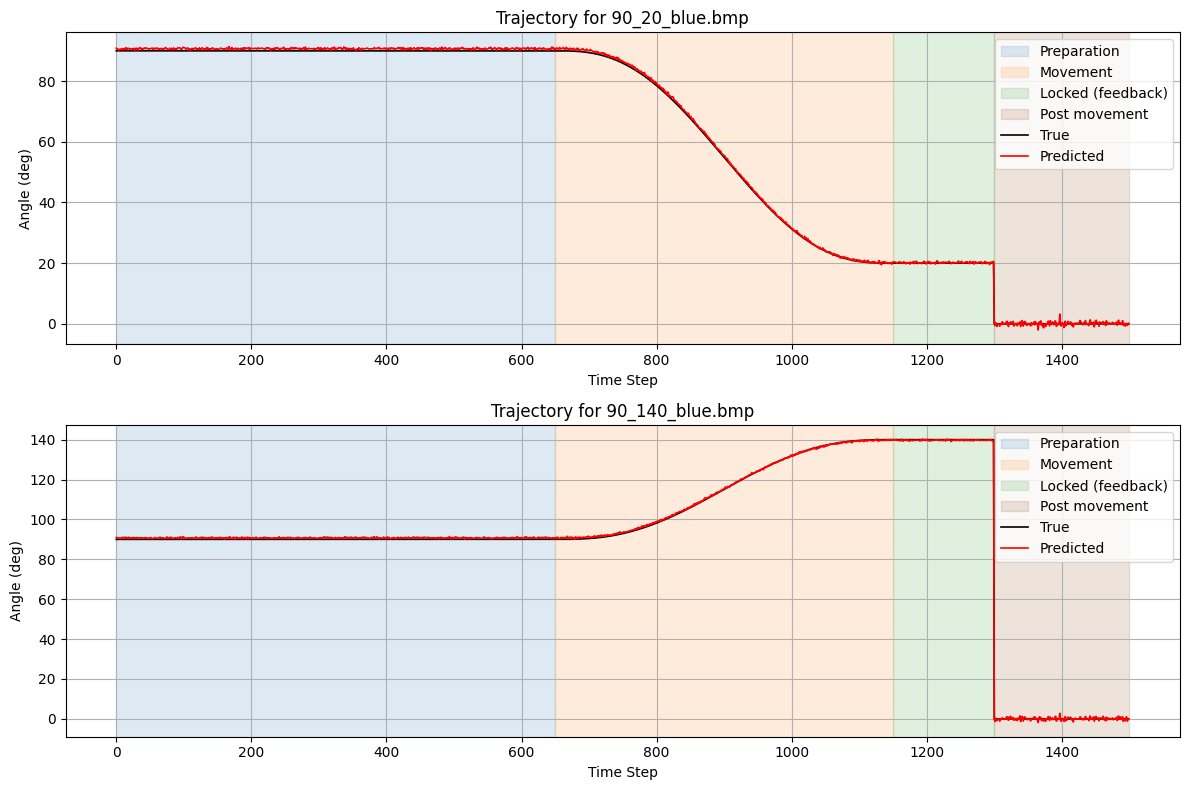


--- Evaluation Complete ---
Final Angle Accuracy (within 1.0°): 100.00%


In [ ]:
print(f"--- Setting up Evaluation for {params.model_type.upper()} Planner ---")

model_path = PLANNER_MODEL_DIR / "trained_gle_planner.pth"
if not model_path.exists():
    raise FileNotFoundError(f"ERROR: Model not found at {model_path}. Please train it first.")

print(f"Loading planner (vision net + trajectory generator) from: {PLANNER_MODEL_DIR}")
planner = get_planner(params, model_dir=PLANNER_MODEL_DIR)  # loads BOTH networks' pretrained weights

print("\nGenerating predictions and calculating accuracy...")

post_phase_steps = int((params.time_grasp + params.time_post) / params.resolution)
angle_comparison_index = -post_phase_steps if post_phase_steps > 0 else -1
print(f"Comparing final angles at index: {angle_comparison_index}")

time_prep_steps = int(params.time_prep / params.resolution)
time_move_end_steps = int((params.time_prep + params.time_move) / params.resolution)

correct_choices = 0
correct_angles = 0
predicted_trajectories = []

num_samples = len(task_data["imgs_path"])
fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4 * num_samples), squeeze=False)
axes = axes[:, 0]  # flatten the (num_samples, 1) column into a 1-D array of Axes

for i in range(num_samples):
    image_path = task_data["imgs_path"][i]
    true_trajectory = task_data["traj_target"][i]

    predicted_trajectory, _ = planner.image_to_trajectory(image_path)
    predicted_trajectories.append(predicted_trajectory)

    """if predicted_choice == task_data["target_choice"][i]:
        correct_choices += 1"""

    if np.isclose(predicted_trajectory[angle_comparison_index],
                   true_trajectory[angle_comparison_index],
                   atol=np.deg2rad(1.0)):
        correct_angles += 1

    close_pts = np.isclose(predicted_trajectory, true_trajectory, atol=np.deg2rad(1.0))
    print(f"Sample {i}: {np.sum(close_pts)}/{len(close_pts)} points within 1° "
          f"({100 * np.mean(close_pts):.1f}%)")

    ax = axes[i]

    boundaries = [0, time_prep_steps, time_move_end_steps, time_locked_with_feedback_end_steps-1, len(target_traj)]
    llabels = ["Preparation", "Movement", "Locked (feedback)", "Post movement"]
    colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#8B4513"]

    for start, end, label, color in zip(boundaries[:-1], boundaries[1:], labels, colors):
        ax.axvspan(start, end, color=color, alpha=0.15, label=label, zorder=0)

    ax.plot(np.rad2deg(true_trajectory), label="True", color="black", linewidth=1.2, zorder=3)
    ax.plot(np.rad2deg(predicted_trajectory), label="Predicted", color="red", linewidth=1.2, zorder=3)
    ax.set_title(f"Trajectory for {Path(image_path).name}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Angle (rad)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

#choice_accuracy = 100 * correct_choices / num_samples
angle_accuracy = 100 * correct_angles / num_samples
print(f"\n--- Evaluation Complete ---")
#print(f"Choice Accuracy: {choice_accuracy:.2f}%")
print(f"Final Angle Accuracy (within 1.0°): {angle_accuracy:.2f}%")

# **Motor Command Generator**

In this section, we introduce the **Motor Command Generator**: a recurrent spiking neural network (RSNN) model inspired by the **primary motor cortex (M1)** that learns to transform desired kinematic reaching trajectories into continuous motor commands.

---

### Architecture Overview

The processing pipeline is organized into four sequential functional stages:

1. **Trajectory Spike Generators**  
   Tracking neurons that encode the desired joint-angle trajectory into spike trains via an **inhomogeneous Poisson process**.

2. **Radial Basis (RB) Input Neurons**  
   A layer that processes incoming spike trains:
   * Estimates the instantaneous firing rate of incoming spikes using a **100 ms sliding window**.
   * Evaluates this rate through a **Gaussian tuning curve** centered on each neuron's preferred input rate.
   * Emits new Poisson-distributed spike trains to drive the recurrent reservoir.

3. **Recurrent Spiking Reservoir (M1 Dynamics)**  
   A recurrent population modeling the internal dynamics of M1, comprising:
   * **Excitatory neurons**: Leaky Integrate-and-Fire (**LIF**) and Adaptive LIF (**ALIF**) neurons.
   * **Inhibitory neurons**: Standard **LIF** neurons.

4. **Non-Spiking Readout Neurons**  
   Two leaky integrator neurons representing the **positive** and **negative** directional motor commands.  
   Unlike the reservoir neurons, readouts do not emit spikes; their **continuous membrane potentials** are integrated over time and directly compared against target motor signals to compute the error.

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="notebooks/imgs/M1_model_paper_Agnes.png" width="50%">
</div>

### Training via Event-Driven Eligibility Propagation (e-prop)

The recurrent reservoir is trained using **Eligibility Propagation (e-prop)**, specifically following the event-driven formulation proposed by *A. Korcsak-Gorzo et al. (2026)*. 

Unlike standard backpropagation, **e-prop runs entirely forward in time**. At each time step, weight updates are factorized into two local components:

$$\Delta W_{ji}(t) \propto - \underbrace{L_j(t)}_{\text{Learning Signal}} \times \underbrace{e_{ji}(t)}_{\text{Eligibility Trace}}$$

* **Eligibility Trace ($e_{ji}$)** — *Local Synaptic Memory ("Was this connection active recently?"):*  
  Maintained locally at each individual synapse. Whenever the pre-synaptic neuron spikes and the post-synaptic neuron responds, the synapse creates a temporary memory trace that slowly fades over time. This trace acts as an open window: it says, *"I participated in the network's recent activity, so I am eligible to be modified if an error happens next."*

* **Learning Signal ($L_j$)** — *Top-Down Error Feedback ("Was there an error?"):*  
  Broadcast from the readout layer to reservoir neuron $j$. It instantly conveys how much that specific neuron's current activity is contributing to the global motor error.

By multiplying the local synaptic trace with the top-down learning signal, synapses update their weights online whenever an error occurs, without needing non-local gradient computations across time.

> 📌 **Technical Note:**  
> Unlike typical deep learning setups that require PyTorch/TensorFlow for gradient steps, the full forward dynamics and event-driven e-prop updates are handled **natively inside a single NEST simulation run**.

## 1. Setup

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pydantic import BaseModel, ConfigDict, Field
from submodules.motor_cortex_eprop.src.motor_controller_model.config_schema import (
    MotorControllerConfig,
    InferenceConfig,
    TrajectorySpec
)
from submodules.motor_cortex_eprop.src.motor_controller_model.signals import generate_training_signals
from submodules.motor_cortex_eprop.src.motor_controller_model.m1_factory import get_m1_or_train
from submodules.motor_cortex_eprop.src.motor_controller_model.run_m1 import run_inference_test

from motor_controller_model.plot_results import (
    tutorial_plot_loss_curve,
    tutorial_plot_spike_raster,
    tutorial_plot_output_vs_target,
    tutorial_plot_post_training_output_vs_target,
)

In [7]:
config = MotorControllerConfig.from_yaml(
    "notebooks/M1_docs/M1_results/config.yaml"
)

training_cfg = config.training
step_ms = params.resolution

## 2. Data creation and visualization

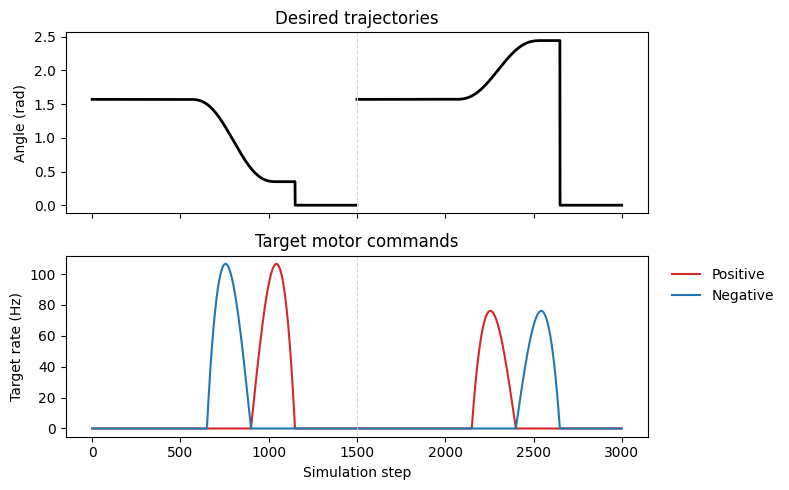

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

offset = 0

for traj in config.training.trajectories:
    signal = generate_training_signals(
        traj,
        training_cfg,
        step_ms,
        config.task.input_shift_ms,
    )

    n = len(signal.input_trajectory)
    t = np.arange(n) + offset

    ax[0].plot(t, signal.input_trajectory, "k", lw=2)
    ax[1].plot(t, signal.target_rates_pos, color="tab:red")
    ax[1].plot(t, signal.target_rates_neg, color="tab:blue")

    if offset:
        for a in ax:
            a.axvline(offset, color="0.85", ls="--", lw=0.8)

    offset += n

ax[0].set(
    title="Desired trajectories",
    ylabel="Angle (rad)",
)

ax[1].set(
    title="Target motor commands",
    xlabel="Simulation step",
    ylabel="Target rate (Hz)",
)

# Legenda FUORI dal grafico
ax[1].plot([], [], color="tab:red", label="Positive")
ax[1].plot([], [], color="tab:blue", label="Negative")

ax[1].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
)

plt.tight_layout()
plt.show()

## 3. Training evaluation

Here we inspect the model's behavior after **500 training iterations** on the **two trajectories** defined in the *Action Selection & Planning* section.

The table below contrasts the network's performance **before and after training** on the identical input dataset.

> 🔍 **Observations & Ongoing Work:**  
> While the post-training readouts clearly show convergence toward the target motor commands, some **trial-to-trial variability and residual noise** remain. Improving readout stability and reducing variance in recurrent spiking dynamics under e-prop is an active area of ongoing research.

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="notebooks/M1_docs/M1_results/spikes_and_dynamics.png" width="50%">
</div>

## 4. Inference test

In [41]:
artifacts_dir = Path("notebooks/M1_results")
artifacts_dir.mkdir(exist_ok=True)

network = get_m1_or_train(
    config=config,
    artifacts_dir=artifacts_dir,
    force_retrain=False,
    nest_module="custom_stdp_module"
)

run_inference_test(config, network, artifacts_dir, "custom_stdp_module")


2026-10-01 15:37:18 [info     ] config matches, loading weights artifacts_dir=notebooks/M1_results


2026-10-01 15:37:18 [debug    ] weights loaded                 path=notebooks/M1_results/trained_weights.npz

Oct 01 15:37:18 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Oct 01 15:37:18 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Oct 01 15:37:18 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Oct 01 15:37:18 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.
2026-10-01 15:37:18 [debug    ] building M1 network            mode=inference

Oct 01 15:37:18 Install [Info]: 
    loaded module custom_stdp_module
2026-10-01 15:37:18 [debug    ] M1 network built and ready for integration

Oct 01 15:37:18 ConnectionManager [Warning]: 
    New connections created, connection descriptors previously obtained using 
    'GetConnections' are now invalid.
2026-10-01 15:37:18 [debug    ] simulating inference           sim_time_ms=3000.0

Oct 01 15:37

(array([ -6.66138074,  -9.75044165, -12.68884728, ...,  -6.05925427,
         -6.49648503,  -2.0482636 ]),
 array([ -6.66138074,  -9.75044165, -12.68884728, ...,  -9.09847676,
         -8.99278016,  -5.29035297]))

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="notebooks/M1_docs/M1_results/standalone_inference_test.png" width="50%">
</div>

# **Cerebellum models**

In this section, we introduce the **cerebellar models**. We first focus on the **structural network elements**, specifically the neuronal cell types and their synaptic connectivity, via network reconstruction. We then examine the **dynamical characteristics** of these models to analyze and understand their behavior.

---

## 1. Setup

In [ ]:
from bsb import from_storage
import numpy as np
import matplotlib.pyplot as plt
from cerebellar_models.analysis.spiking_results import BasicSimulationReport
from cerebellar_models.analysis.structure_analysis import StructureReport

## Reconstruction of the network: 

The reconstruction of the circuit is **managed by the Brain Scaffold Builder repo v7** (**BSB**) (De Schepper et al. 2022), where placement, spatial orientation, morphologies, and connectcome rules are defined. The models are validated against population-specific firing frequencies, considering both in-vitro and in-vivo awake states. 

### Reconstruction procedure

Compile the network architecture from the YAML configuration file. This reconstructs the cerebellar volume, executes cell placement, generates the connectome, and writes the assembled scaffold into the HDF5 storage format.

1. **Run the reconstruction:** <br>
    `mpirun -n [num_proc] bsb compile notebooks/docs/circuit.yml –clear` 

    - **Note:** The `--clear` flag ensures any existing HDF5 file with the same name is deleted and reconstructed from scratch.

2. **Report Generation:** <br>
    Run the code cell below to obtain a report that summarizes the structural characteristics of the network reconstructed:

In [ ]:
reco_file = "/notebooks/docs/cerebellum_microzones.hdf5" # file generated during the reconstruction of the network
reco_pdf = "notebooks/docs/reco_microzones.pdf" # pdf that can be generated immediately after the reconstruction

# RECONSTRUCTION REPORT
report_struct = StructureReport(reco_file)
report_struct.print_report(reco_pdf)

<div style="display: flex; justify-content: center; gap: 100px; align-items: center;">
    <img src="notebooks/imgs/network_with_legend.png" width="30%">
    <img src="notebooks/imgs/tables_network_cerebellum_together.png" width="40%">
</div>

## Simulation: 

Execute the neural simulation using the compiled HDF5 scaffold generated in Step 1. This produces parallel `.nio`  output files (one per processor) that, once aggregated, allow for the analysis of population-level electrophysiological analysis (e.g., spike trains, membrane potentials, and firing rates across all cerebellar cell types).

### Learning rule: Long-Term Synaptinc Plasticity

**Supervised learning at parallel fiber–Purkinje cell (pf-PC) synapses** under **Inferior Olive (IO)** supervision:
* **IO fires** (error signal through climing fibers):** Coincident Pf excitation and Cf discharge (indicating an error signal) trigger a sustained **decrease in synaptic efficacy at the active Pf–PC synapses** (**Long-Term Depression**).
* **No IO activity** (no error):** Repetitive Pf excitation in the absence of CF error signals leads to the p**rogressive strengthening of active PF–PC synapses**.

<div style="display: flex; ">
    <img src="notebooks/imgs/plasticity_cerebellum.png" width="50%">
</div>

### Experimental Protocol: Eyeblink Classical Conditioning (EBCC)
The simulation replicates a standard associative plasticity protocol (Eyeblink Conditioning):
- **Conditioned Stimulus (CS):** A rectangular mossy fiber (MF) input delivered at **40 Hz for 260 ms**.
- **Unconditioned Stimulus (US):** A high-frequency burst (spike input) delivered to Inferior Olive (IO) neurons during the **last 10 ms** of the MF stimulus.
- **Repetition:** The paired CS-US sequence is delivered across **two successive trials** to observe induction and expression of cerebellar synaptic plasticity.

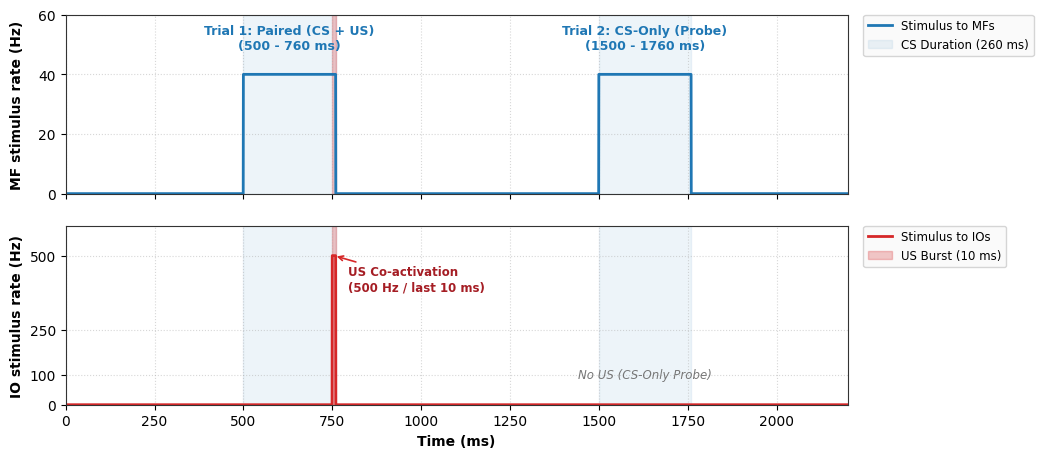

In [20]:
# --- 1. Protocol Parameters ---
dt = 0.5  # Time step in ms
total_time = 2200.0  # Total duration in ms
t = np.arange(0, total_time, dt)

# Protocol timings
trial_onsets = [500.0, 1500.0]  # First trial at 500 ms, second at 1500 ms
cs_duration = 260.0  # Mossy Fiber (CS) duration (ms)
us_burst_duration = 10.0  # Inferior Olive (US) burst duration (ms)
cs_freq = 40.0  # MF rate (Hz)
us_burst_freq = 500.0  # IO burst rate (Hz)

# Initialize signal arrays
mf_rate = np.zeros_like(t)
io_rate = np.zeros_like(t)

# --- 2. Construct Stimulation Waveforms ---
for idx, cs_start in enumerate(trial_onsets):
    cs_stop = cs_start + cs_duration

    # Conditioned Stimulus (MF Rate Profile) - both trials
    mf_mask = (t >= cs_start) & (t < cs_stop)
    mf_rate[mf_mask] = cs_freq

    # Unconditioned Stimulus (IO Rate Profile) - ONLY Trial 1 (idx == 0)
    if idx == 0:
        us_start = cs_stop - us_burst_duration
        us_stop = cs_stop
        io_mask = (t >= us_start) & (t < us_stop)
        io_rate[io_mask] = us_burst_freq

# --- 3. Figure Setup & Styling ---
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "axes.edgecolor": "#333333",
        "axes.linewidth": 0.8,
    }
)

fig, (ax_cs, ax_us) = plt.subplots(
    2,
    1,
    figsize=(11.5, 5.0),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.18},
)

# --- Top Panel: Mossy Fibers (CS) ---
ax_cs.plot(t, mf_rate, color="#1f77b4", lw=2, label="Stimulus to MFs")
ax_cs.set_ylabel("MF stimulus rate (Hz)", fontsize=10, fontweight="bold")
ax_cs.set_ylim(bottom=0, top=60)
ax_cs.set_yticks([0, 20, 40, 60])
ax_cs.grid(True, linestyle=":", alpha=0.5)

# --- Bottom Panel: Inferior Olive (US) ---
ax_us.plot(t, io_rate, color="#d62728", lw=2, label="Stimulus to IOs")
ax_us.set_ylabel("IO stimulus rate (Hz)", fontsize=10, fontweight="bold")
ax_us.set_xlabel("Time (ms)", fontsize=10, fontweight="bold")
ax_us.set_ylim(bottom=0, top=600)
ax_us.set_yticks([0, 100, 250, 500])
ax_us.set_xlim(0, total_time)
ax_us.grid(True, linestyle=":", alpha=0.5)

# Align Y-labels horizontally across both panels
fig.align_ylabels([ax_cs, ax_us])

# --- 4. Alignment & Annotations ---
for idx, cs_start in enumerate(trial_onsets):
    cs_stop = cs_start + cs_duration

    # Shaded region for CS across both panels
    for ax in (ax_cs, ax_us):
        ax.axvspan(
            cs_start,
            cs_stop,
            color="#1f77b4",
            alpha=0.08,
            label="CS Duration (260 ms)" if idx == 0 and ax == ax_cs else "",
        )

    # Shaded region and annotation for US ONLY in Trial 1
    if idx == 0:
        us_start = cs_stop - us_burst_duration
        for ax in (ax_cs, ax_us):
            ax.axvspan(
                us_start,
                cs_stop,
                color="#d62728",
                alpha=0.25,
                label="US Burst (10 ms)" if ax == ax_us else "",
            )

        ax_us.annotate(
            "US Co-activation\n(500 Hz / last 10 ms)",
            xy=(us_start + 5, us_burst_freq),
            xytext=(us_start + 45, 420),
            arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.2),
            fontsize=8.5,
            fontweight="semibold",
            color="#a51d24",
            va="center",
        )

    # Trial header (Top panel)
    trial_type = "Paired (CS + US)" if idx == 0 else "CS-Only (Probe)"
    ax_cs.text(
        cs_start + cs_duration / 2,
        52,
        f"Trial {idx + 1}: {trial_type}\n({int(cs_start)} - {int(cs_stop)} ms)",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#1f77b4",
    )

# Annotation for unreinforced Trial 2 (Bottom panel)
ax_us.text(
    trial_onsets[1] + cs_duration / 2,
    100,
    "No US (CS-Only Probe)",
    ha="center",
    va="center",
    fontsize=8.5,
    fontstyle="italic",
    color="#777777",
)

# --- 5. Legends Positioned Outside Plot Area ---
ax_cs.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="#cccccc",
    fontsize=8.5,
)
ax_us.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="#cccccc",
    fontsize=8.5,
)

# Adjust layout to guarantee identical subplots geometry
plt.subplots_adjust(left=0.10, right=0.78, top=0.90, bottom=0.12)
plt.show()

### Simulation procedure

1. **Run the simulation:** <br>
 `mpirun -n [num_proc] bsb simulate mouse_cerebellum_microzones.hdf5 mf_cf_stimulus` 

    - **Note:** `mf_cf_stimulus` specifies the simulation protocol to run. Check the configuration `.yml` file for all available simulation names.

2. **Report Generation:**  <br>
   Ensure all `.nio` output files generated in step 1 are placed in the designated directory (ex.`notebooks/docs/nio_folder/`) and then, run the code cell below to process the data and generate the report.

In [ ]:
nio_folder = "notebooks/docs/nio_folder" # folder in which put all the .nio files generated during the simulation
sim_stim_pdf = "report_trials_noplast_no_mfdcn_2.pdf" # pdf for the report of the simulation
scaffold = from_storage(reco_file)

# SIMULATION REPORT
report_sim_stim = BasicSimulationReport(
    scaffold, simulation_name="mf_cf_stimulus", folder_nio=nio_folder
)
report_sim_stim.print_report(sim_stim_pdf)

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="notebooks/imgs/rates_and_raster_plots_together.png" width="80%">
</div>

# **The whole controller**

In this section, we integrate all the individual components introduced earlier into a **unified closed-loop neurocontroller** to generate the target robotic behavior.

---

### Experimental Task & Setup
* **Embodiment:** The task is executed in **PyBullet** using a **1-DoF virtual arm** (elbow flexion/extension);
* **Vision-Driven Task (Deep Learning Planner):** The robot performs reaching toward a ball (red or blue). The pre-trained planner processes the visual scene, **extracts visual features**, and produce both the reaching trajectory and the conditional post-grasp decision;
* **Adaptive dynamics:** The controller is evaluated under different dynamic conditions (with or without **gravity**), serving as an external dynamical disturbance.

### Learning & Adaptation Across Trials
Training the neurocontroller across **multiple trials** enables it to **progressively improve real-time motor control** and **adapt online to external dynamic perturbations** (such as gravity).

<div style="display:flex; gap:40px;">

<video width="38%" utoplay loop muted>
    <source src="notebooks/video/actual_anim_red_complete.mp4" type="video/mp4">
</video>

<img src="notebooks/imgs/Inverse_model-first_vs_last_trial.jpg" width="35%">

</div>

> 💡 **Note on Post-Grasp Kinematics:**  
> The post-grasp shoulder sliding phase is not simulated via spiking neural dynamics. Instead, it is an **open-loop, scripted velocity command** in PyBullet. The motion's direction is chosen by the **visual planner** based on the detected object color during the initial scene evaluation.

## Experimental Evaluation: Parameter Exploration

Now, let's run several experiments under different parameter settings to analyze behavioral changes and demonstrate the critical role of the cerebellum in motor adaptation. 

> **Note on Simulation Runtime:**  
> To maintain practical execution times during this hands-on session, the **live simulation** is configured to run for **only a few initial iterations**. This brief run illustrates the neurocontroller's baseline execution, immediate closed-loop dynamics, and initial synaptic weight updates. Subsequently, pre-computed results from full **120-iteration** executions are loaded to examine the optimal behaviours of the neurocontroller.

## 1. Setup

In [1]:
from neurocontroller.run_trials import run_trial_nrp
import structlog
import sys
from neurocontroller.config.MasterParams import MasterParams
from neurocontroller.config.core_models import ExperimentParams
from neurocontroller.config.connection_params import ConnectionsParams

log = structlog.get_logger()

## 2. Run the simulation

Before running the comparative experiments, you can customize the neurocontroller and physical environment by editing the corresponding configuration files:

#### 1. Enable / Disable the Cerebellar Network
To toggle the entire cerebellum on or off:
* **File:** `src/neurocontroller/config/MasterParams.py`
* **Parameter:**
  ```python 
  USE_CEREBELLUM: bool = True  # Set to False to run purely without cerebellar control 
  ```

### 2. Isolate Forward vs. Inverse Cerebellar Models
While there is **no dedicated boolean switch** for the forward and inverse modules, you can functionally disable either loop by **zeroing its corresponding Deep Cerebellar Nuclei (DCN) output** weight:

* **File:** `src/neurocontroller/config/connection_params.py`
* **Parameter:**
    * **Disable Forward Model (sensorimotor prediction):**
    ```python 
    dcn_forw_prediction = 0.0  # Default connection weight from DCN forward module 
    ```
    * **Disable Inverse Model (motor command correction):**
    ```python 
    dcn_i_motor_prediction = 0.0  # Default connection weight from DCN inverse module 
    ```

### 3. Configure Gravity
To test adaptation under/without gravity (external force):
* **File:** `src/neurocontroller/config/core_models.py`
* **Class:** `ExperimentParams`
* **Parameters:** Configure gravity state and magnitude.

Now, we have everything to run the neurocontroller:

2026-10-02 23:08:40 [info     ] --- Starting NRP Trial 1/1 ---
2026-10-02 23:08:40 [info     ] Starting a new simulation chain.
2026-10-02 23:08:40 [debug    ] SimulationConfig loaded and dumped successfully. in /sim/controller/runs/20261002230840_z111-hands_on_tutorial_experiment_cerebellum_inv/params20261002230840_z111_simconfig.json
[2026-10-02 23:08:41.032] [info] Working directory: [ /sim/controller ]
2026-10-02 23:08:42 [debug    ] Starting NRP, logs in /sim/controller/runs/20261002230840_z111-hands_on_tutorial_experiment_cerebellum_inv/logs/nrpcore_log.log
2026-10-02 23:09:43 [debug    ] Nrp server initialized successfully
2026-10-02 23:09:43 [info     ] Start run loop. 1 trial (1500 total iterations)


2026-10-02 23:10:31 [debug    ] Simulation time: 47.6 s       


2026-10-02 23:11:07 [info     ] --- Generating Plots (Standalone) ---
2026-10-02 23:11:07 [info     ] Generating plant plots...     
2026-10-02 23:11:07 [info     ] Initializing PlantConfig...   
2026-10-02 23:11:07 [info     ] PlantConfig initialized successfully from MasterConfig
2026-10-02 23:11:08 [info     ] Saved joint RMSE plot at /sim/controller/runs/20261002230840_z111-hands_on_tutorial_experiment_cerebellum_inv/figs_robotic/elbow_rmse_20261002_231107.png
2026-10-02 23:11:08 [info     ] Saved joint space plot at /sim/controller/runs/20261002230840_z111-hands_on_tutorial_experiment_cerebellum_inv/figs_robotic/position_joint_20261002_231108.png
2026-10-02 23:11:08 [info     ] Saved motor commands plot at /sim/controller/runs/20261002230840_z111-hands_on_tutorial_experiment_cerebellum_inv/figs_robotic/motCmd_20261002_231108.png
2026-10-02 23:11:08 [info     ] Saved error per trial plot at at /sim/controller/runs/20261002230840_z111-hands_on_tutorial_experiment_cerebellum_inv/figs

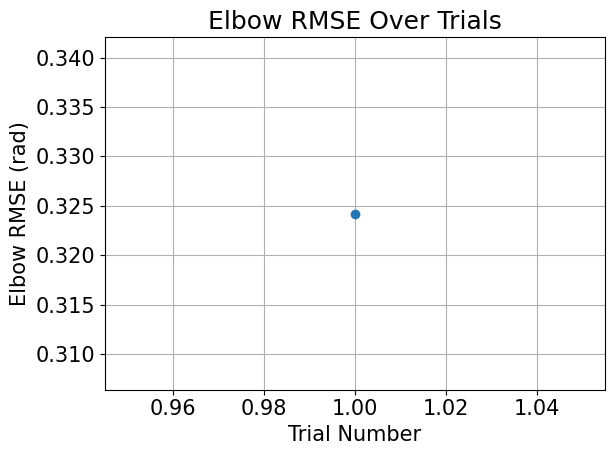

In [ ]:
num_trials = 1
current_parent_id = ""
label = "hands_on_tutorial_experiment"

for i in range(num_trials):
    try:
        run_id = run_trial_nrp(
            i + 1, num_trials, current_parent_id, label
        )
        current_parent_id = run_id
    except RuntimeError:
        log.error("Aborting simulation chain due to error.")
        sys.exit(1)
    except KeyboardInterrupt:
        log.warning("Simulation chain interrupted by user.")
        sys.exit(130)

        current_parent_id = run_id

### What happen during the execution?

<div style="display:flex; gap:40px;">
<img src="notebooks/imgs/activity_of_whole_controller_during_one_trial.jpg" width="100%">
</div>

<div style="display:flex; gap:40px;">
<img src="notebooks/imgs/activity_of_whole_controller_during_all_trials.jpg" width="100%">
</div>

## 3. Evaluation of results

### Without Cerebellum

<div style="display:flex; gap:40px;">
<img src="notebooks\imgs\results_without_cerebellum.JPG" width="100%">
</div>

### With Cerebellum

<div style="display:flex; gap:40px;">
<img src="notebooks\imgs\results_with_cerebellum.JPG" width="100%">
</div>